Objective
Evaluate whether Linear Regression assumptions are satisfied.
Dataset
Participants must choose any real-world dataset with continuous target.
Examples:
• car price prediction
• medical cost dataset
• housing dataset
Tasks
Train Linear Regression model and check assumptions:
1. Linearity
2. Normal distribution of residuals
3. Homoscedasticity
4. Independence of errors
Required Plots
Participants must generate:
• Residual plot
• QQ plot
• Histogram of residuals
• Predicted vs Actual
Questions
1. Are residuals normally distributed?
2. Is there heteroscedasticity?
3. How would you fix violations?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import scipy.stats as stats

In [2]:
df = pd.read_csv("housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
X = df[['area','bedrooms','bathrooms','stories','parking']]
y = df['price']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
y_pred = model.predict(X_test)

In [7]:
residuals = y_test - y_pred

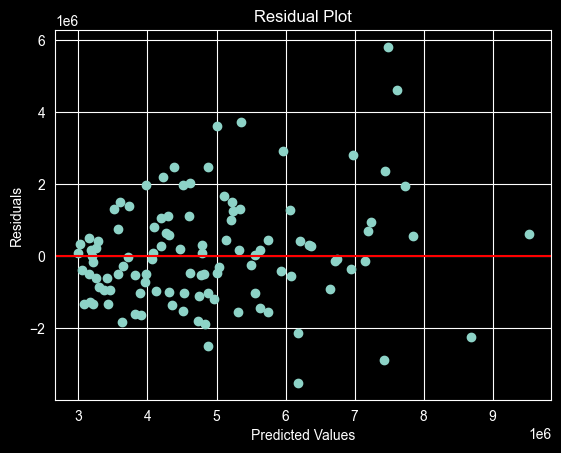

In [13]:
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

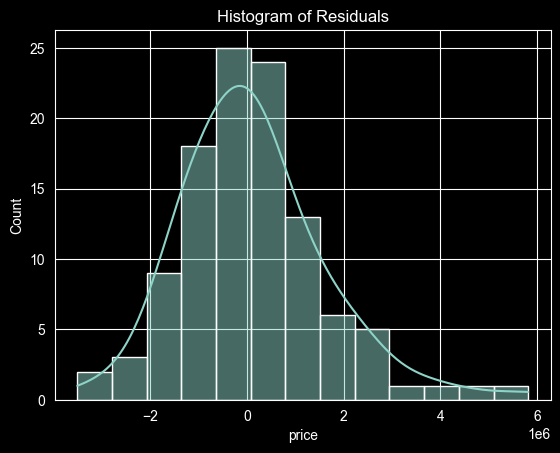

In [14]:
sns.histplot(residuals, kde=True)
plt.title("Histogram of Residuals")
plt.show()

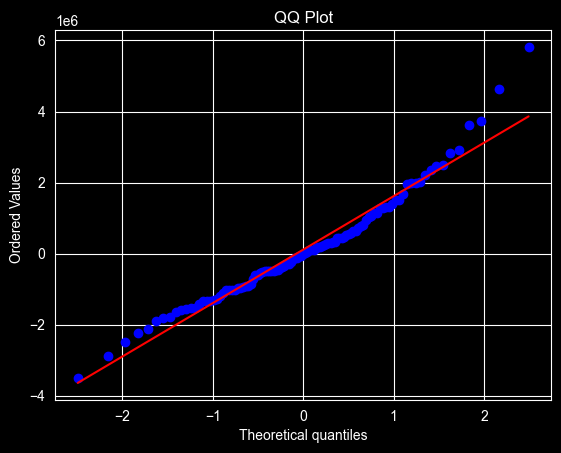

In [15]:
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot")
plt.show()

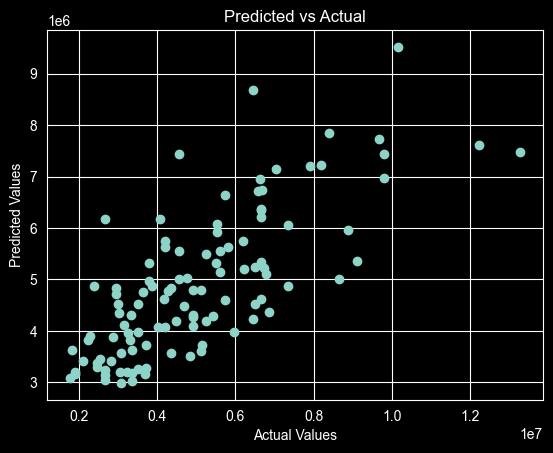

In [16]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual")
plt.show()

Are residuals normally distributed?

Yes, if:

Histogram shows bell-shaped distribution

QQ plot points lie close to straight line

This indicates residuals follow normal distribution.

Is there heteroscedasticity?

Check Residual Plot.

If residual spread is constant, there is no heteroscedasticity.

If spread increases or decreases, heteroscedasticity exists.

How would you fix violations?
If Linearity is violated

Use:

Polynomial Regression

Decision Trees

Random Forest